# Lecture 15 - Exercise - Explore the noisy detector signal

In [330]:
#-------------------------------------------------------------------------
# importing libraries and setting up nice plots
#-------------------------------------------------------------------------

import os
import time
import corner
import requests
import numpy                        as np
import matplotlib                   as mpl
import matplotlib.pyplot            as plt
import matplotlib.patches           as patches
from   matplotlib                   import rc
from   matplotlib.colors            import to_hex
from   mpl_toolkits.axes_grid1      import make_axes_locatable
from   sys                          import stdout
from   scipy                        import stats, integrate
from   astroML                      import stats as astroMLstats
from   astropy.visualization.hist   import hist  as fancyhist
from   astropy.cosmology            import Planck15
from   sklearn.neighbors            import KernelDensity
from   sklearn.manifold             import Isomap
from   sklearn.cluster              import KMeans
from   sklearn.neighbors            import KNeighborsClassifier
from   sklearn.metrics              import confusion_matrix, accuracy_score
from   sklearn.model_selection      import train_test_split, GridSearchCV
from   sklearn.linear_model         import LogisticRegression
from   sklearn.mixture              import GaussianMixture
from   sklearn.decomposition        import PCA, NMF, FastICA

#-------------------------------------------------------------------------

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif" : ["Times New Roman"],
	"font.size"  : 9,
    "figure.dpi" : 300
    })
plt.rc('text.latex', preamble=r'\usepackage{amssymb}')

current_pwd = os.getcwd()
print(current_pwd)

#-------------------------------------------------------------------------

D:\Documents\University\Magistrale\Statistics\GitHub\working


In [331]:
#-------------------------------------------------------------------------
# Load data
#-------------------------------------------------------------------------

signal = np.load('noisydetector.npy').T
print(signal.shape)

# the x_axis wasn't included in "noisydetector.npy" but it's part of the exercise
time = np.linspace(0, 8, signal.shape[1])    
print(time.shape)

#-------------------------------------------------------------------------

(3, 2000)
(2000,)


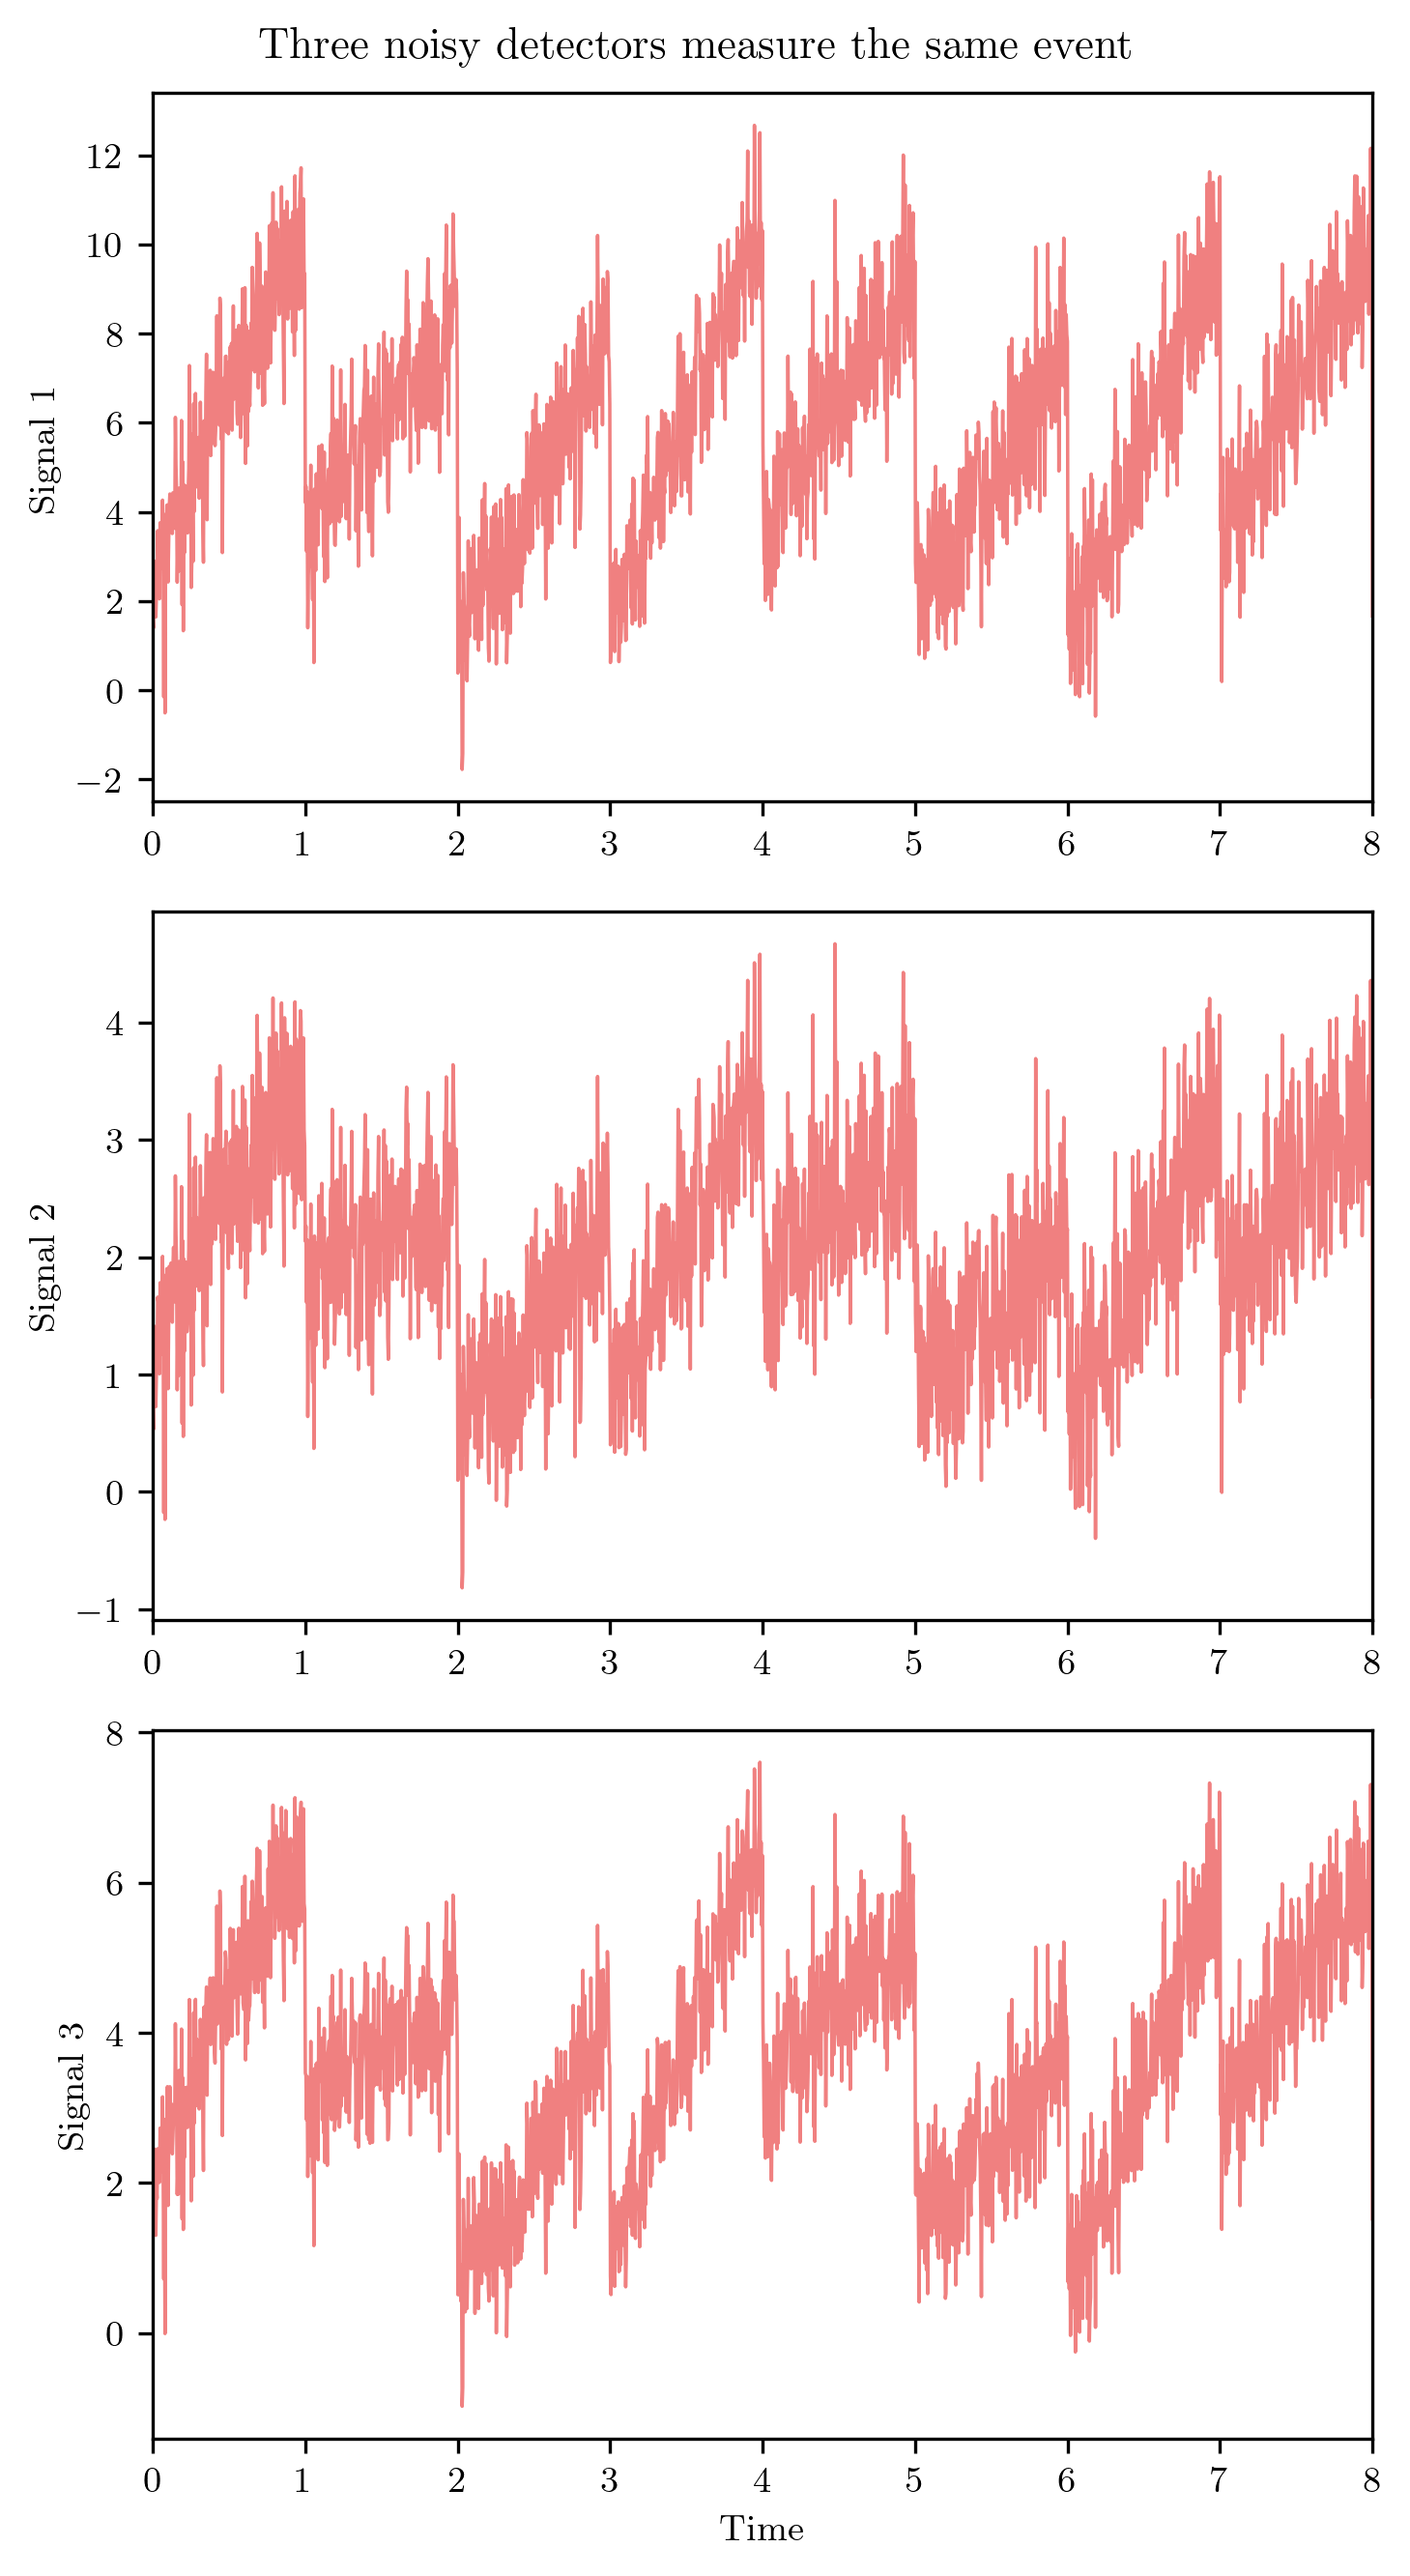

In [332]:
#-------------------------------------------------------------------------
# plot the three measured noisy signals
#-------------------------------------------------------------------------

fig, ax = plt.subplots(3,1,figsize=(5,9))
ax = ax.reshape(3)

for i in range(3):
    ax[i].set_xlim(0,8)
    ax[i].plot(time, signal[i,:], color='lightcoral', lw=0.85)
    ax[i].set_ylabel('Signal {:d}'.format(i+1))
ax[-1].set_xlabel('Time')
fig.suptitle('Three noisy detectors measure the same event')
fig.tight_layout()

#-------------------------------------------------------------------------

In [333]:
#-------------------------------------------------------------------------
# Let us now define the various techniques for dimensionality reduction
#-------------------------------------------------------------------------

#-------------------------------------------------------------------------
# Principal Component Anlaysis (isolating mean)
# as in lecture L15 - treat: n_samples=3 (number of measurements), n_features=2000 (wavelength bins)

def L15_PCA(data, n_components=3):

    pca = PCA(n_components-1)
    data_trasformed = pca.fit_transform(data)

    n_comps = pca.n_components_
    data_mean = np.mean(data, axis=0)[:,np.newaxis].T
    data_components  = pca.components_
    data_eigenvalues = pca.explained_variance_ratio_  

    return n_comps, data_mean, data_components, data_eigenvalues, data_trasformed

#-------------------------------------------------------------------------
# Principal Component Anlaysis (isolating mean)
# As in I don't care - treat: n_samples=2000 (number of wavelengths), n_features=3 (number of measurements)

def new_PCA(data, n_components=3):

    skl_data = data.T
    pca = PCA(n_components-1)
    data_eigenvalues = pca.fit_transform(skl_data)

    n_comps = pca.n_components_
    data_mean = np.mean(skl_data, axis=1)[:,np.newaxis]
    data_components = pca.components_
    data_eigenfava = pca.explained_variance_ratio_  

    return n_comps, data_mean, data_components, data_eigenvalues, data_eigenfava

#-------------------------------------------------------------------------
# Non-negative Matrix Factorization


def dimreduct_NMF(data, ):

    return 

#-------------------------------------------------------------------------
# Independent Component Anlaysis

def dimreduct_ICA(data, ):

    return 

#-------------------------------------------------------------------------

In [334]:
PCA1_n_components, signal_mean1, PCA1_components, PCA1_eigenvalues, PCA1_transform = L15_PCA(signal, n_components=3)

print('Lecture 15 method, n_components:')
print(PCA1_n_components)
print('signal shape: n_samples=3 vectors of n_features=2000')
print(signal.shape)
print('1st eigenvector = mean of 3 signals: 1 vector of n_f=2000')
print(signal_mean1.shape)
print('2nd, 3rd eigenvectors: 2 vectors of n_f=2000')
print(PCA1_components.shape)
print('transformed data: (3 sets of 2 eigenvalues?)')
print(PCA1_transform.shape)
print('percentage of variance encoded in the 2 eigenvalues (???)')
print(PCA1_eigenvalues.shape)
print(PCA1_eigenvalues)

Lecture 15 method, n_components:
2
signal shape: n_samples=3 vectors of n_features=2000
(3, 2000)
1st eigenvector = mean of 3 signals: 1 vector of n_f=2000
(1, 2000)
2nd, 3rd eigenvectors: 2 vectors of n_f=2000
(2, 2000)
transformed data: (3 sets of 2 eigenvalues?)
(3, 2)
percentage of variance encoded in the 2 eigenvalues (???)
(2,)
[0.98906501 0.01093499]


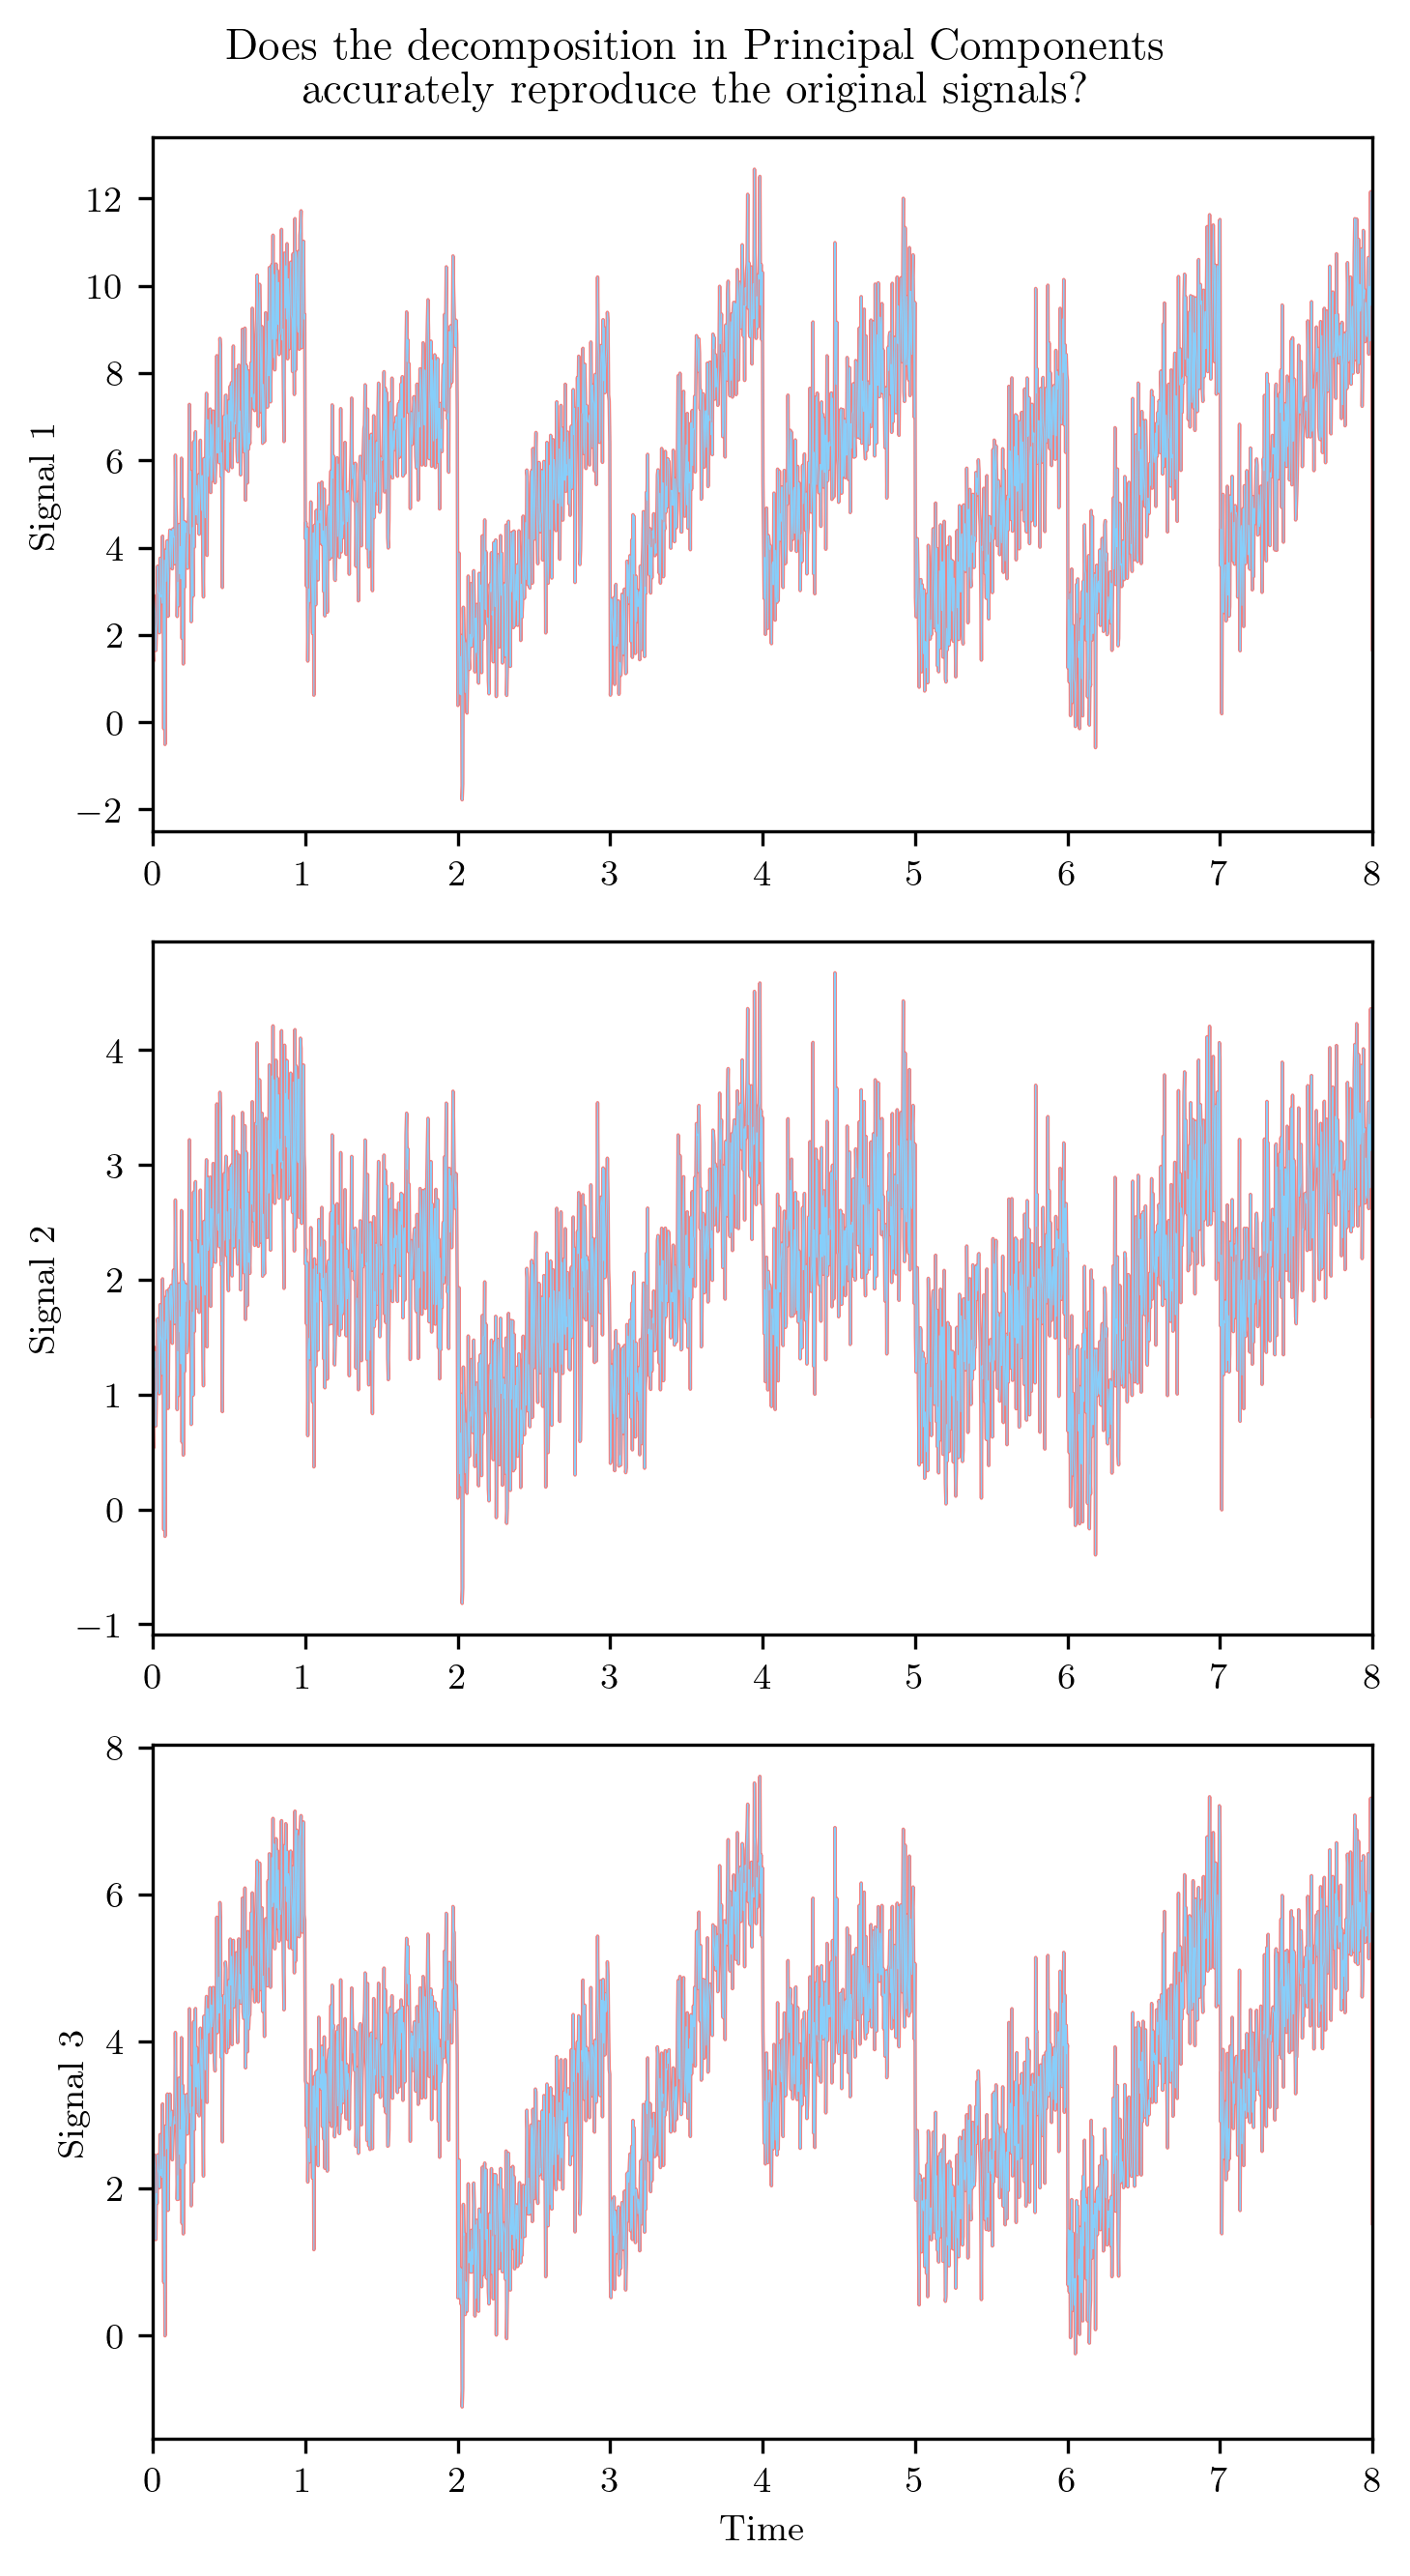

In [335]:
#-------------------------------------------------------------------------
# check that with the PCA decomposition we reconstruct the signals
#-------------------------------------------------------------------------

fig, ax = plt.subplots(3,1,figsize=(5,9))

# coeff = np.dot( PCA_eigenvalues , PCA_components - signal_mean )
# print(coeff.shape)

def coeff_i1(x_i,m,e_1,e_2):
    e_11 = np.dot(e_1,e_1)
    e_12 = np.dot(e_1,e_2)
    e_22 = np.dot(e_2,e_2)
    f = (e_11 - e_12**2/e_22)**(-1)
    e_1im = np.dot( e_1 , x_i - m)
    e_2im = np.dot( e_2 , x_i - m)
    g = e_1im - e_2im * e_12/e_22
    return f * g
    
for i in range(3):
    ax[i].plot(time, signal[i,:], color='lightcoral', lw=0.85)
    ax[i].set_xlim(0,8)
    ax[i].set_ylabel('Signal {:d}'.format(i+1))
ax[2].set_xlabel('Time')

comp_1 = np.copy(signal_mean1[0,:])
for j in range(PCA1_n_components):
    comp_1 += np.copy(PCA1_transform[0,j]) * np.copy(PCA1_components[j,:])
ax[0].plot(time, comp_1, color='lightskyblue', lw=0.25)
del comp_1

comp_2 = np.copy(signal_mean1[0,:])
for j in range(PCA1_n_components):
    comp_2 += np.copy(PCA1_transform[1,j]) * np.copy(PCA1_components[j,:])
ax[1].plot(time, comp_2, color='lightskyblue', lw=0.25)
del comp_2

comp_3 = np.copy(signal_mean1[0,:]) 
for j in range(PCA1_n_components):
    comp_3 += np.copy(PCA1_transform[2,j]) * np.copy(PCA1_components[j,:])
ax[2].plot(time, comp_3, color='lightskyblue', lw=0.25)
del comp_3

fig.suptitle('Does the decomposition in Principal Components\naccurately reproduce the original signals?')

fig.tight_layout()

#-------------------------------------------------------------------------

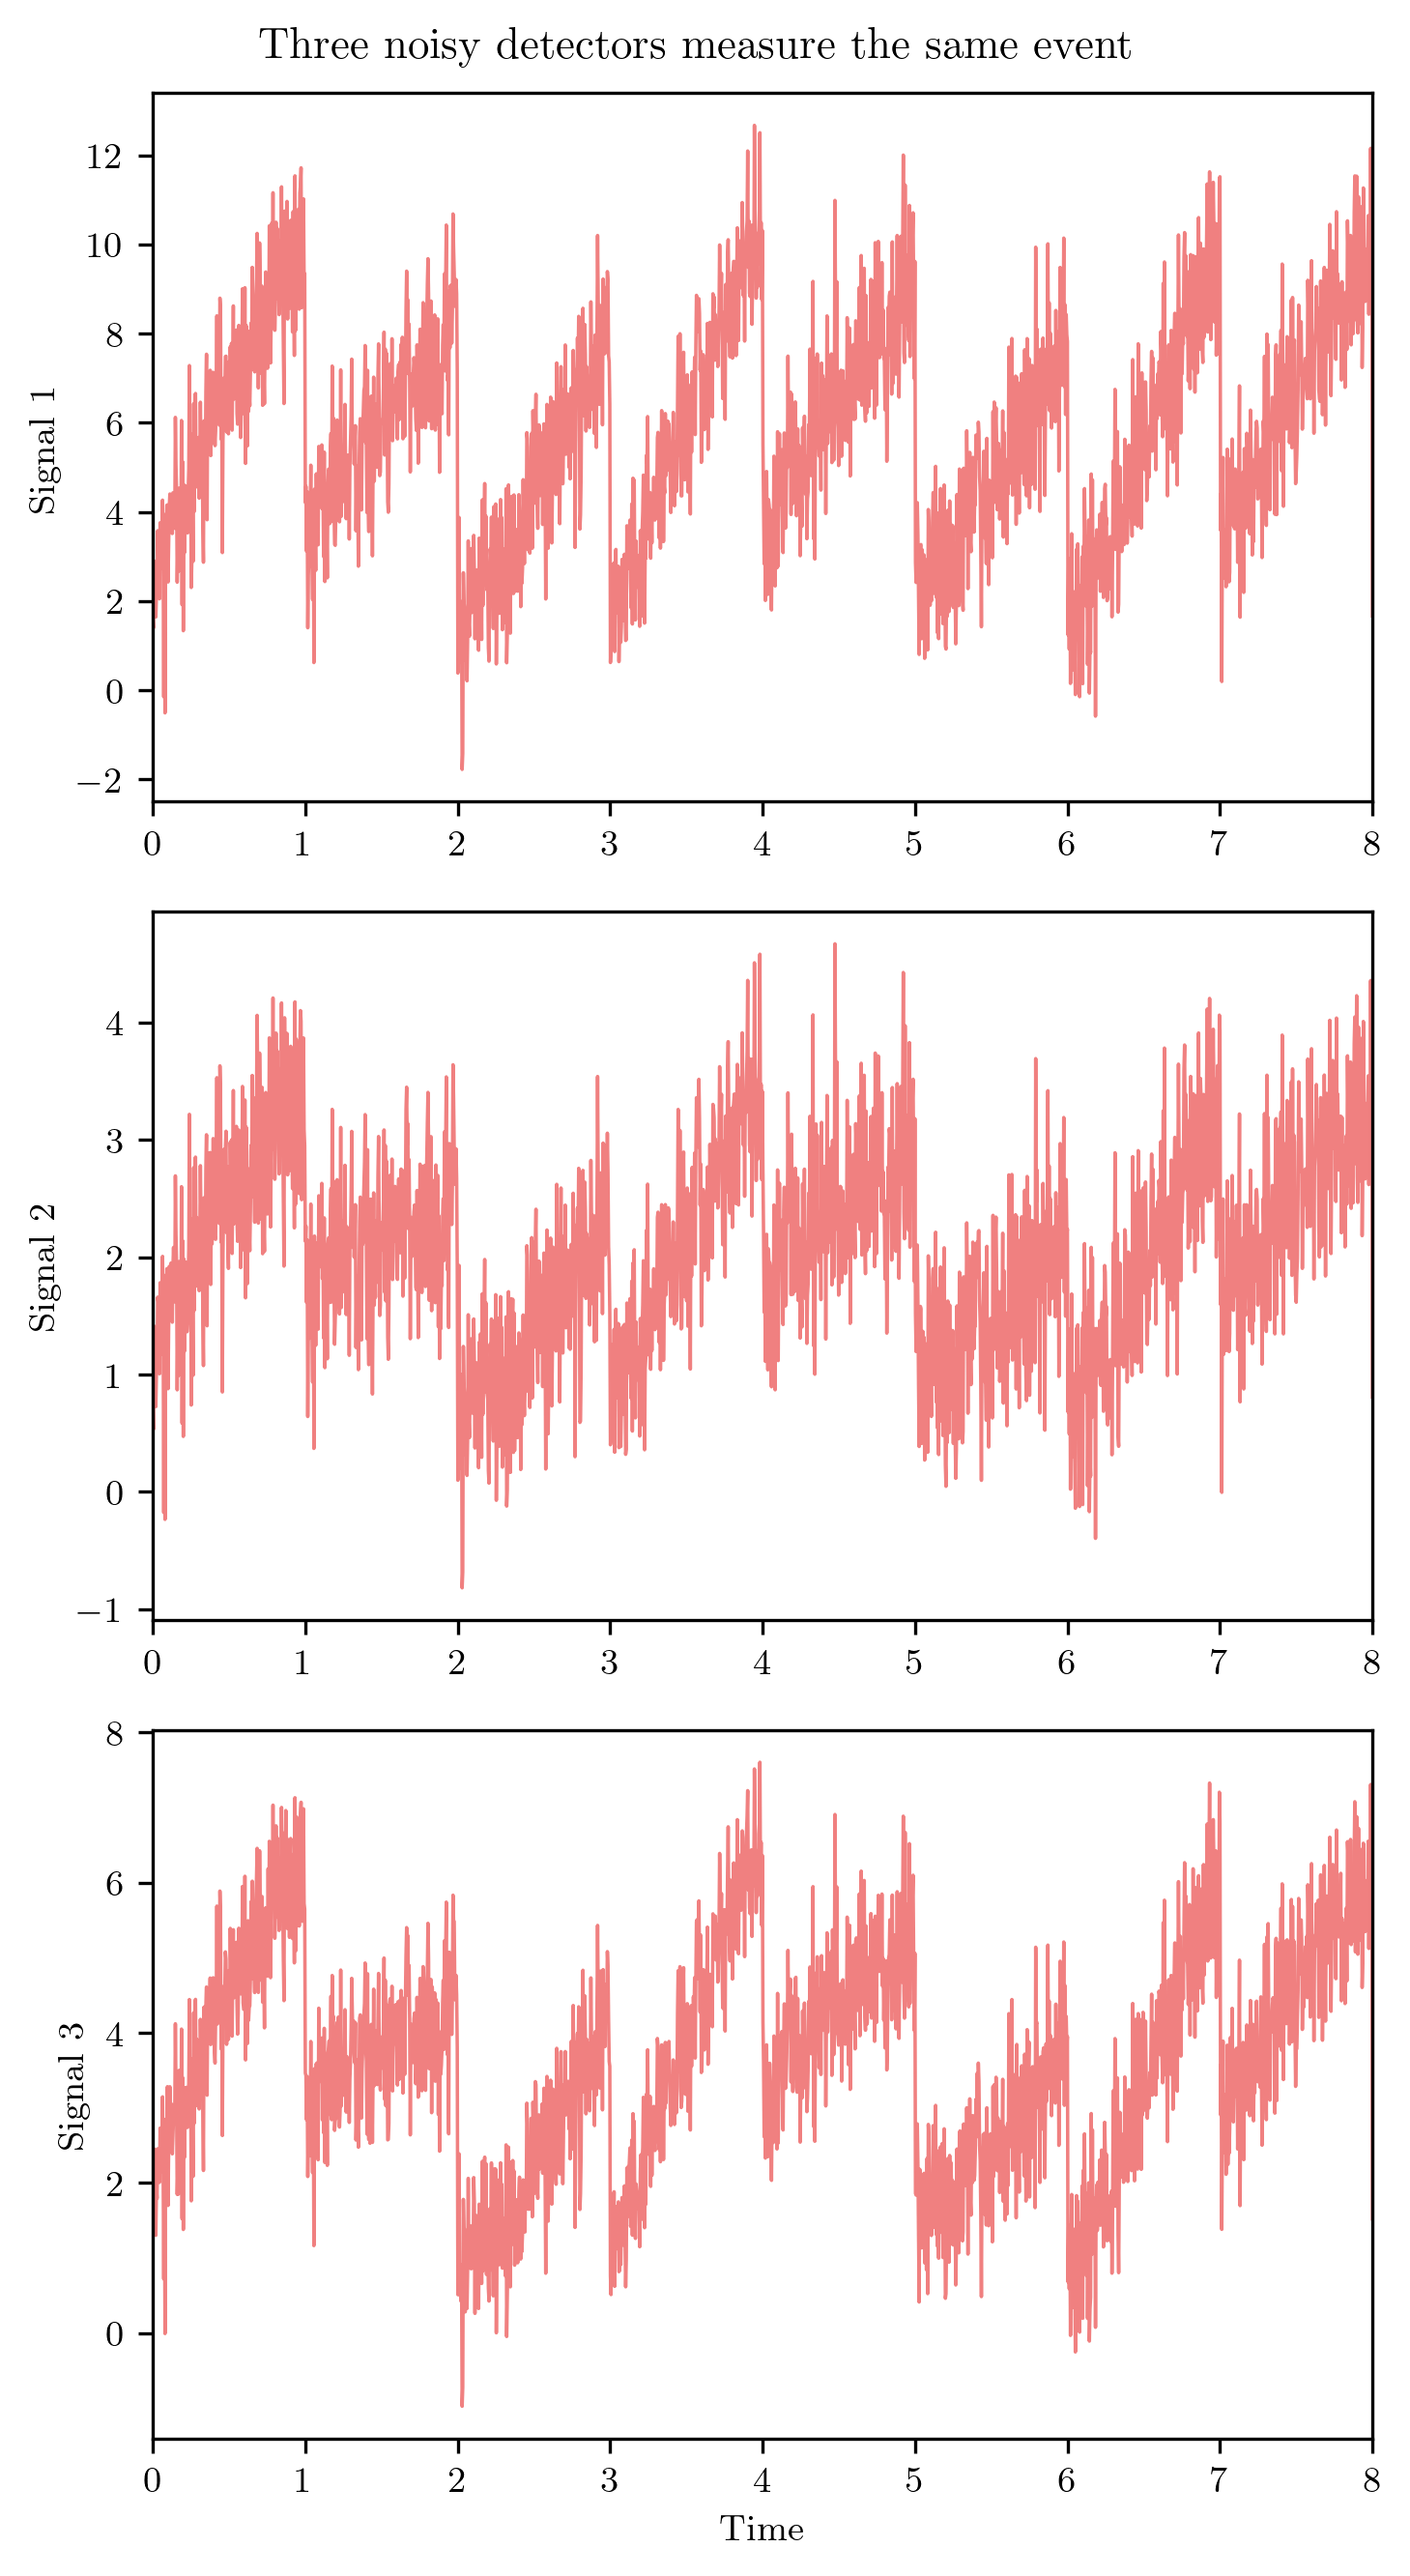

In [336]:
#-------------------------------------------------------------------------
# plot the three measured noisy signals
#-------------------------------------------------------------------------

fig, ax = plt.subplots(3,1,figsize=(5,9))
ax = ax.reshape(3)

for i in range(3):
    ax[i].set_xlim(0,8)
    ax[i].plot(time, signal[i,:], color='lightcoral', lw=0.85)
    ax[i].set_ylabel('Signal {:d}'.format(i+1))
ax[-1].set_xlabel('Time')
fig.suptitle('Three noisy detectors measure the same event')
fig.tight_layout()

#-------------------------------------------------------------------------

In [337]:

PCA2_n_components, signal_mean2, PCA2_components, PCA2_eigenvalues, PCA2_eigenfava = new_PCA(signal, n_components=3)
print('Opposite method, n_components:')
print(PCA2_n_components)
print('signal shape: n_samples=2000 vectors of n_features=3')
print(signal.T.shape)
print('1st eigenvector = mean of 3 signals: 1 vector of n_s=2000')
print(signal_mean2.shape)
print('2nd, 3rd eigenvectors: 2 vectors of n_f=3')
print(PCA2_components.shape)
print('eigenvalues: 2000 sets of 2 eigenvalues')
print(PCA2_eigenvalues.shape)
print(PCA2_eigenvalues)


Opposite method, n_components:
2
signal shape: n_samples=2000 vectors of n_features=3
(2000, 3)
1st eigenvector = mean of 3 signals: 1 vector of n_s=2000
(2000, 1)
2nd, 3rd eigenvectors: 2 vectors of n_f=3
(2, 3)
eigenvalues: 2000 sets of 2 eigenvalues
(2000, 2)
[[-4.72245942  0.56926604]
 [-5.18916004  0.34258643]
 [-3.27051193  0.43438793]
 ...
 [ 4.38829648 -0.15805047]
 [ 6.00762947 -0.41793282]
 [-4.84174243  0.35054743]]
